# Tripolar fold functionality: relative vorticity across the Arctic seam

Tripolar ocean grids (MOM6, NEMO, Oceananigans) cover the Arctic with a
**bipolar cap** whose northern edge **folds** onto itself. Relative vorticity

$$\zeta = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$$

is the natural diagnostic that *exposes* the fold: the northernmost
$\partial u/\partial y$ reaches across the pole, and the fold both mirrors the
zonal axis and **flips the sign** of the folded velocity. Treating the grid as
merely zonally periodic ("naive") therefore gets the Arctic vorticity wrong
right at the seam.

This notebook computes $\zeta$ **two ways** — naive (X-periodic only) and
fold-aware — for **all three models**, and shows the difference is localized
*exactly* at the fold row. xgcm expresses the fold as a single per-axis boundary,

```python
boundary={"X": "periodic", "Y": {"fold": <pivot>}}
```

with the pivot set by each model's grid generation: **MOM6** and **NEMO** use an
F-point (`"corner"`) pivot, **Oceananigans** uses `"u"`.

> **Dependencies** — the NEMO section reads CMIP6 from the Pangeo cloud
> (`pip install zarr gcsfs`); the MOM6 section downloads ~230 MB from Zenodo.

In [1]:
import os
import urllib.request

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from xgcm import Grid

## The fold-aware vorticity, in one helper

`grid.diff(v, "X")` is unaffected by the fold (X is periodic), but
`grid.diff(u, "Y")` crosses the northern seam — so we pass it as a vector
component (`{"X": u}` with its `other_component`) on the fold grid, which mirrors
**and sign-flips** the folded halo. The naive version uses a plain fill at the
northern edge.

In [2]:
def naive_and_fold_vorticity(coords_ds, gridcoords, u, v, fold_pivot):
    '''Return (zeta_naive, zeta_fold) = dv/dx - du/dy, computed with an
    X-periodic-only grid and with the tripolar north fold, respectively.'''
    def make(y_boundary):
        return Grid(coords_ds, coords=gridcoords,
                    boundary={"X": "periodic", "Y": y_boundary},
                    autoparse_metadata=False)

    g_naive, g_fold = make("fill"), make({"fold": fold_pivot})
    dvdx = g_fold.diff(v, "X", boundary="fill")                 # X periodic -> fold irrelevant
    dudy_naive = g_naive.diff(u, "Y", boundary="fill", fill_value=0.0)
    dudy_fold = g_fold.diff({"X": u}, "Y", other_component={"Y": v}, boundary="fill")
    return dvdx - dudy_naive, dvdx - dudy_fold


def show_fold_effect(zeta_naive, zeta_fold, label, nrows=12):
    '''Plot the northern `nrows` of naive / fold-aware vorticity and their
    difference (index space), and report where the two disagree.'''
    yname = zeta_fold.dims[0]
    diff = zeta_naive - zeta_fold
    lim = float(np.nanpercentile(np.abs(zeta_fold.values), 99)) or 1.0
    panels = [(zeta_naive, "naive (X-periodic only)", lim),
              (zeta_fold, "fold-aware", lim),
              (diff, "naive - fold", lim)]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
    for ax, (d, title, vlim) in zip(axes, panels):
        arr = d.isel({yname: slice(-nrows, None)}).values
        im = ax.imshow(arr, origin="lower", aspect="auto", cmap="RdBu_r",
                       vmin=-vlim, vmax=vlim)
        ax.set(title=f"{label}: {title}", xlabel="zonal index i",
               ylabel=f"rows below the seam")
        fig.colorbar(im, ax=ax, shrink=0.85)
    plt.tight_layout()
    plt.show()
    seam = float(np.nanmax(np.abs(diff.isel({yname: -1}).values)))
    below = float(np.nanmax(np.abs(diff.isel({yname: slice(0, -1)}).values)))
    print(f"{label}: max|naive - fold|  at seam = {seam:.4g};  below seam = {below:.4g}")

## Oceananigans (`TripolarGrid`, `"u"` pivot)

The small generated dataset (see
[`07_oceananigans_tripolar.ipynb`](07_oceananigans_tripolar.ipynb)). `u` sits on
the X-face, `v` on the Y-face; the vorticity lands on the NE corner, whose top
row needs the folded neighbour.

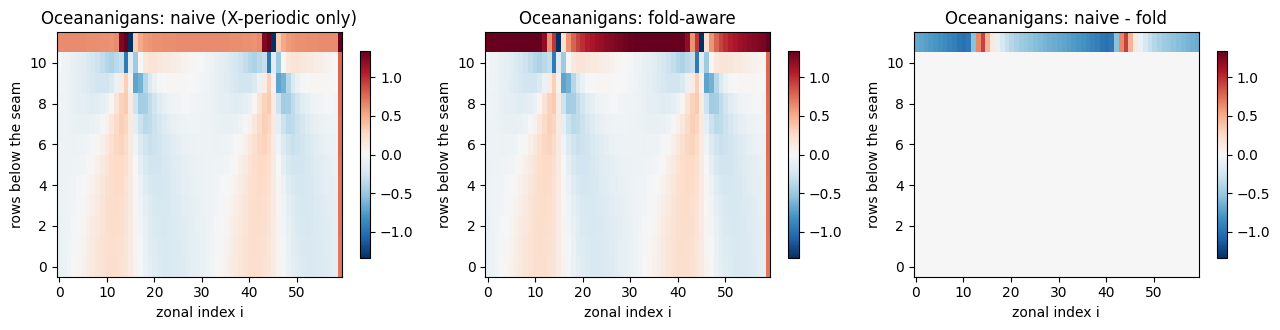

Oceananigans: max|naive - fold|  at seam = 0.9984;  below seam = 0


In [3]:
o = xr.open_dataset("oceananigans_tripolar.nc")
ny, nx = o["tracer"].shape
oc = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
u = o["u"].transpose("y_c", "x_f").assign_coords(x_f=oc["x_f"], y_c=oc["y_c"])
v = o["v"].transpose("y_f", "x_c").assign_coords(x_c=oc["x_c"], y_f=oc["y_f"])

zN, zF = naive_and_fold_vorticity(
    xr.Dataset(coords=oc),
    {"X": {"center": "x_c", "right": "x_f"}, "Y": {"center": "y_c", "right": "y_f"}},
    u, v, fold_pivot="u")
show_fold_effect(zN, zF, "Oceananigans")

## NEMO eORCA1 (IPSL-CM6A-LR, `"corner"` pivot)

Real CMIP6 surface currents read anonymously from the Pangeo cloud. CMIP6 masks
the redundant northern row, so we drop it before folding. `uo` is the U-point,
`vo` the V-point.

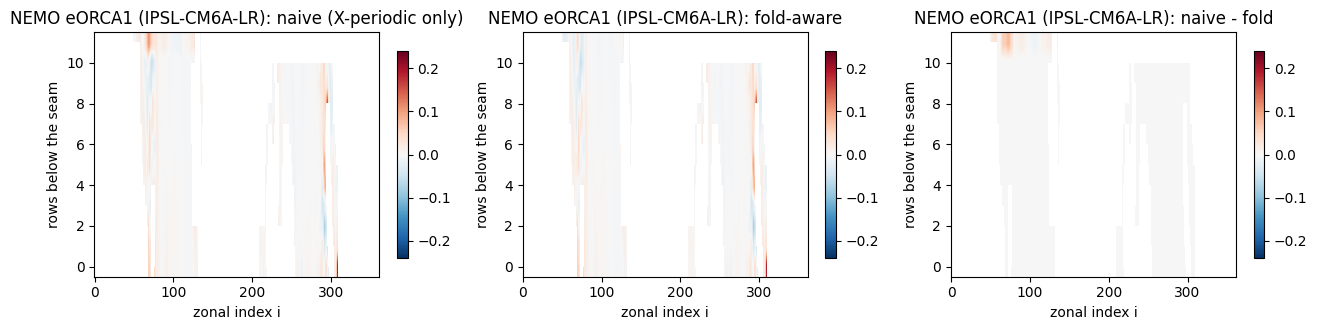

NEMO eORCA1 (IPSL-CM6A-LR): max|naive - fold|  at seam = 0.07767;  below seam = 0


In [4]:
base = ("gs://cmip6/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/historical/"
        "r1i1p1f1/Omon/{var}/gn/v20180803/")
so = {"storage_options": {"token": "anon"}}


def _surface(var):
    da = xr.open_dataset(base.format(var=var), engine="zarr", backend_kwargs=so)
    return da[var].isel(time=0, olevel=0)


uo = _surface("uo").isel(y=slice(0, -1))    # drop the masked northern fold row
vo = _surface("vo").isel(y=slice(0, -1))
ny, nx = uo.shape
nc = dict(x_c=np.arange(nx), x_f=np.arange(nx), y_c=np.arange(ny), y_f=np.arange(ny))
u = xr.DataArray(uo.values, dims=["y_c", "x_f"]).assign_coords(x_f=nc["x_f"], y_c=nc["y_c"])
v = xr.DataArray(vo.values, dims=["y_f", "x_c"]).assign_coords(x_c=nc["x_c"], y_f=nc["y_f"])

zN, zF = naive_and_fold_vorticity(
    xr.Dataset(coords=nc),
    {"X": {"center": "x_c", "right": "x_f"}, "Y": {"center": "y_c", "right": "y_f"}},
    u, v, fold_pivot="corner")
show_fold_effect(zN, zF, "NEMO eORCA1 (IPSL-CM6A-LR)")

## MOM6 (CM4X, `"corner"` pivot)

Full-resolution global MOM6 output (see
[`03_MOM6.ipynb`](03_MOM6.ipynb)). The depth-integrated mass transports `umo`
(U-point) and `vmo` (V-point) live on `outer` positions, so the vorticity corner
naturally includes the northern edge.

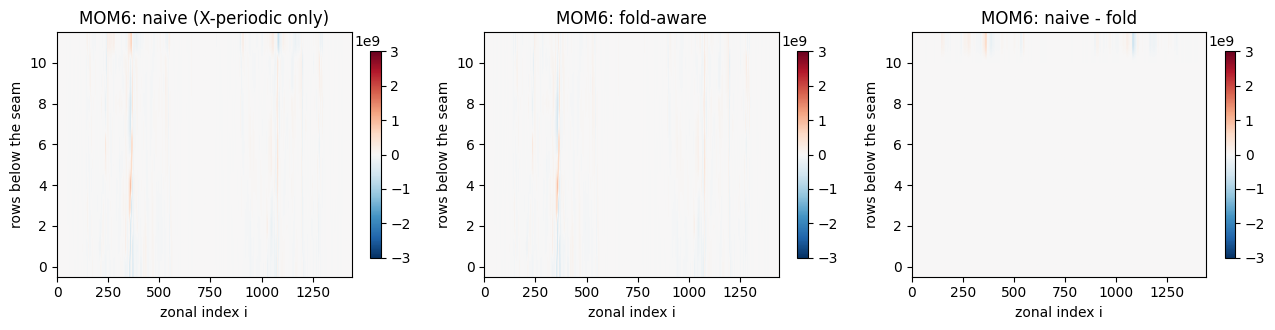

MOM6: max|naive - fold|  at seam = 7.149e+08;  below seam = 0


In [5]:
url = ("https://zenodo.org/api/records/15420739/files/"
       "MOM6_global_example_vertically_integrated_mass_budget_v0_0_6.nc/content")
fname = "MOM6_global_example_mass_budget.nc"
if not os.path.exists(fname):
    urllib.request.urlretrieve(url, fname)
m = xr.open_dataset(fname, decode_times=False).isel(time=0)

zN, zF = naive_and_fold_vorticity(
    m,
    {"X": {"center": "xh", "outer": "xq"}, "Y": {"center": "yh", "outer": "yq"}},
    m["umo"], m["vmo"], fold_pivot="corner")
show_fold_effect(zN, zF, "MOM6")

## Takeaway

For **all three** tripolar conventions, the naive (X-periodic-only) and
fold-aware relative vorticity are identical everywhere **except the single fold
row**, where the naive calculation is wrong because it cannot see the velocity
across the pole. xgcm's `boundary={"Y": {"fold": ...}}` mirrors the seam and
sign-flips the folded velocity automatically, giving the physically correct
Arctic vorticity — the same machinery, with only the pivot (`"corner"` for
MOM6/NEMO, `"u"` for Oceananigans) differing between models.

See the [grid topology](../grid_topology.md) docs for the full fold
specification, and [`03_MOM6.ipynb`](03_MOM6.ipynb) /
[`07_oceananigans_tripolar.ipynb`](07_oceananigans_tripolar.ipynb) for the
per-model fold checks.